In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

# A. Download and merge data

In [2]:
file = 'data/Pharmacy_Data_Challenge_Dataset.xlsx'

FactSales = pd.read_excel(file, sheet_name='FactSales', engine='openpyxl')
dimProduct = pd.read_excel(file, sheet_name='DimProduct', engine='openpyxl')
dimPharmacy = pd.read_excel(file, sheet_name='DimPharmacy', engine='openpyxl')
dimDate = pd.read_excel(file, sheet_name='DimDate', engine='openpyxl')

In [3]:
print("FactSales shape:", FactSales.shape)

FactSales shape: (62139, 9)


In [4]:
df_analysis: DataFrame  = (
    FactSales
    .merge(dimDate, on='DateKey', how='left')
    .merge(dimPharmacy, on='PharmacyID', how='left', suffixes=('', '_pharmacy'))
    .merge(dimProduct, on='ProductID', how='left', suffixes=('', '_product'))
)

df_analysis.head()


,SalesID,DateKey,PharmacyID,ProductID,UnitsSold,RevenueEUR,CostEUR,MarginEUR,PromoFlag,Date,...,ProductName,Category,Brand,IsGeneric,PackSize,ListPriceEUR,StandardCostEUR,LaunchDate,IsDiscontinued,DiscontinuedDate
0,S0000001,20240101,PH0002,PR0099,5,128.08,87.55,40.53,No,2024-01-01,...,HairEssence Mouthwash Sensitive,Personal Care,HairEssence,No,150 ml,24.63,17.25,2018-12-06,No,NaN
1,S0000002,20240101,PH0004,PR0156,4,51.89,34.32,17.57,No,2024-01-01,...,NatureFit Omega-3 Active,Wellness,NatureFit,No,500 g,16.63,11.87,2021-05-21,No,NaN
2,S0000003,20240101,PH0007,PR0004,20,317.73,199.53,118.20,No,2024-01-01,...,DermaSoft Shampoo Repair,Personal Care,DermaSoft,No,100 ml,15.13,8.83,2018-01-10,No,NaN
3,S0000004,20240101,PH0009,PR0075,6,90.34,67.49,22.85,No,2024-01-01,...,Medica Paracetamol 20 mg,OTC,Medica,No,30 tablets,14.34,11.37,2017-05-26,No,NaN
4,S0000005,20240101,PH0010,PR0154,2,160.21,124.99,35.22,Yes,2024-01-01,...,CareEquip Digital Thermometer Advance,Medical Devices,CareEquip,No,25 strips,91.50,69.26,2025-07-30,No,NaN


In [5]:
#check table's size
print("Merged dataset shape:", df_analysis.shape)

Merged dataset shape: (62139, 34)


The FactSales table contains 62,139 rows and 9 columns.
After merging it with date, pharmacy, and product dimension tables, the final analytical dataset contains 62,139 rows and 34 columns.
The row count remained unchanged, which indicates that the merge did not duplicate or remove sales transactions.

# B. First exploration

## Explore data types

In [6]:
df_analysis.info()

<class 'pandas.DataFrame'>
RangeIndex: 62139 entries, 0 to 62138
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   SalesID           62139 non-null  str           
 1   DateKey           62139 non-null  int64         
 2   PharmacyID        62139 non-null  str           
 3   ProductID         62139 non-null  str           
 4   UnitsSold         62139 non-null  int64         
 5   RevenueEUR        62139 non-null  float64       
 6   CostEUR           62139 non-null  float64       
 7   MarginEUR         62139 non-null  float64       
 8   PromoFlag         62139 non-null  str           
 9   Date              62139 non-null  datetime64[us]
 10  Year              62139 non-null  int64         
 11  Quarter           62139 non-null  int64         
 12  MonthNumber       62139 non-null  int64         
 13  MonthName         62139 non-null  str           
 14  YearMonth         62139 non-null 

In [7]:
df_analysis.describe()

,DateKey,UnitsSold,RevenueEUR,CostEUR,MarginEUR,Date,Year,Quarter,MonthNumber,Latitude,Longitude,ListPriceEUR,StandardCostEUR
count,6.213900e+04,62139.000000,62139.000000,62139.000000,62139.000000,62139,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000,62139.000000
mean,2.024579e+07,7.174126,138.946190,99.982881,38.963309,2025-01-05 21:38:53.664848,2024.512190,2.519641,6.558216,48.120902,8.131152,25.730213,19.507631
min,2.024010e+07,1.000000,1.610000,1.100000,0.440000,2024-01-01 00:00:00,2024.000000,1.000000,1.000000,37.395178,-6.003924,2.060000,1.400000
25%,2.024071e+07,3.000000,55.250000,39.330000,15.140000,2024-07-08 00:00:00,2024.000000,2.000000,4.000000,45.445908,4.392816,10.950000,7.980000
50%,2.025011e+07,6.000000,102.750000,72.220000,28.990000,2025-01-10 00:00:00,2025.000000,3.000000,7.000000,48.850568,6.977880,16.870000,11.610000
75%,2.025071e+07,10.000000,181.350000,128.680000,51.990000,2025-07-09 00:00:00,2025.000000,4.000000,10.000000,51.224739,12.508677,29.150000,21.810000
max,2.025123e+07,25.000000,1036.280000,834.420000,295.310000,2025-12-31 00:00:00,2025.000000,4.000000,12.000000,54.369348,21.030542,111.080000,82.800000
std,5.014700e+03,4.873395,124.574712,93.611370,33.972445,NaN,0.499855,1.114143,3.441730,4.162928,6.222714,23.511095,18.784088


# E. Verifying that sales don't contain any negative values

In [8]:
df_analysis[['UnitsSold',
             'RevenueEUR',
             'CostEUR',
             'MarginEUR']].describe()

,UnitsSold,RevenueEUR,CostEUR,MarginEUR
count,62139.000000,62139.000000,62139.000000,62139.000000
mean,7.174126,138.946190,99.982881,38.963309
std,4.873395,124.574712,93.611370,33.972445
min,1.000000,1.610000,1.100000,0.440000
25%,3.000000,55.250000,39.330000,15.140000
50%,6.000000,102.750000,72.220000,28.990000
75%,10.000000,181.350000,128.680000,51.990000
max,25.000000,1036.280000,834.420000,295.310000


In [9]:
df_analysis[['UnitsSold',
             'RevenueEUR',
             'CostEUR',
             'MarginEUR']].min()



UnitsSold     1.00
RevenueEUR    1.61
CostEUR       1.10
MarginEUR     0.44
dtype: float64

In [10]:
df_analysis[['UnitsSold',
             'RevenueEUR',
             'CostEUR',
             'MarginEUR']].max()

UnitsSold       25.00
RevenueEUR    1036.28
CostEUR        834.42
MarginEUR      295.31
dtype: float64

In [11]:
(df_analysis['RevenueEUR'] >= df_analysis['CostEUR']).all()

np.True_

In [12]:
np.isclose(
    df_analysis["MarginEUR"],
    df_analysis["RevenueEUR"] - df_analysis["CostEUR"],
    atol=0.01
).all()

np.True_

In [13]:
(df_analysis['UnitsSold'] > 0).all()

np.True_

In [14]:
(df_analysis['RevenueEUR'] >= 0).all()

np.True_

In [15]:
(df_analysis['MarginEUR'] >= 0).all()

np.True_

In [16]:
(df_analysis['ListPriceEUR'] > 0).all()

np.True_

In [17]:
(df_analysis['StandardCostEUR'] > 0).all()

np.True_

# D. Check duplicates

In [48]:
full_duplicates_count = df_analysis.duplicated().sum()
print(full_duplicates_count)


0


In [19]:
# 1. Get list of all columns, exclude SalesID
columns_to_check = df_analysis.columns.difference(['SalesID'])

# 2. Looking duplicates there
logical_duplicates_count = df_analysis.duplicated(subset=columns_to_check).sum()
print(f"Found duplicates (different SalesID): {logical_duplicates_count}")

# 3. Look at them
if logical_duplicates_count > 0:
    logical_duplicates = df_analysis[df_analysis.duplicated(subset=columns_to_check, keep=False)]

    # Sort the data to keep identical transactions together
    display(logical_duplicates.sort_values(by=['DateKey', 'PharmacyID', 'ProductID']).head(10))

Found duplicates (different SalesID): 0


##### No duplicate records were found.

In [20]:
df_analysis.isnull().sum()

SalesID                 0
DateKey                 0
PharmacyID              0
ProductID               0
UnitsSold               0
RevenueEUR              0
CostEUR                 0
MarginEUR               0
PromoFlag               0
Date                    0
Year                    0
Quarter                 0
MonthNumber             0
MonthName               0
YearMonth               0
PharmacyName            0
Country                 0
Region                  0
City                    0
PharmacyType            0
OpenDate                0
StoreSizeBand           0
Latitude                0
Longitude               0
ProductName             0
Category                0
Brand                   0
IsGeneric               0
PackSize                0
ListPriceEUR            0
StandardCostEUR         0
LaunchDate              0
IsDiscontinued          0
DiscontinuedDate    57094
dtype: int64

# Explore outliers

<Axes: xlabel='RevenueEUR'>

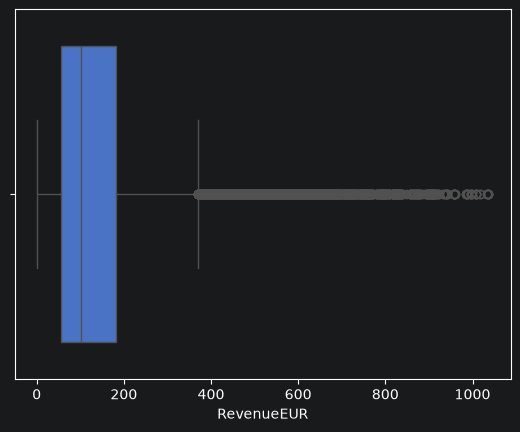

In [21]:
sns.boxplot(x=df_analysis['RevenueEUR'])

<Axes: xlabel='UnitsSold', ylabel='Count'>

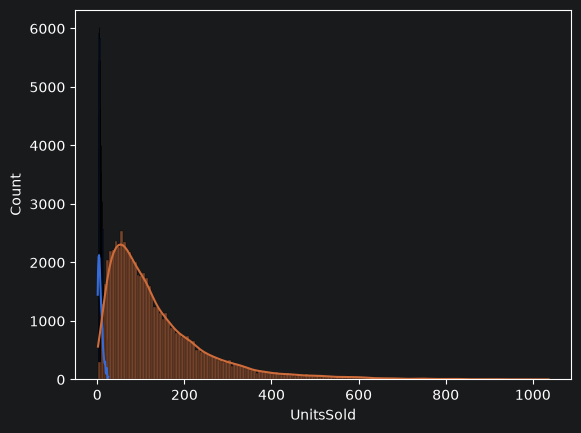

In [49]:
# Распределение RevenueEUR
sns.histplot(df_analysis['RevenueEUR'], kde=True)

<Axes: xlabel='UnitsSold', ylabel='Count'>

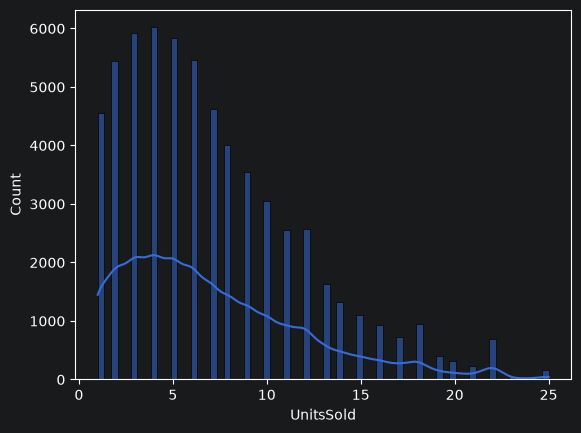

In [50]:
# Распределение UnitsSold
sns.histplot(df_analysis['UnitsSold'], kde=True)

<Axes: >

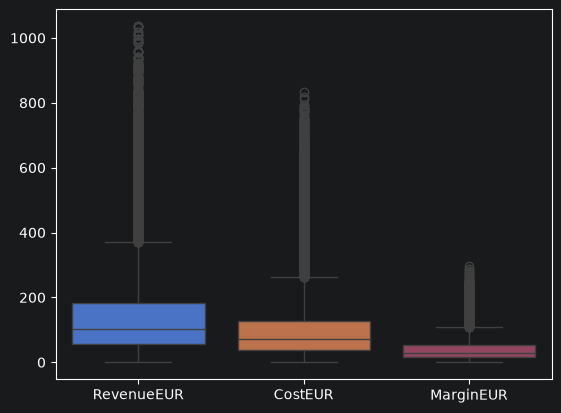

In [22]:
sns.boxplot(data=df_analysis[['RevenueEUR',
                              'CostEUR',
                              'MarginEUR']])

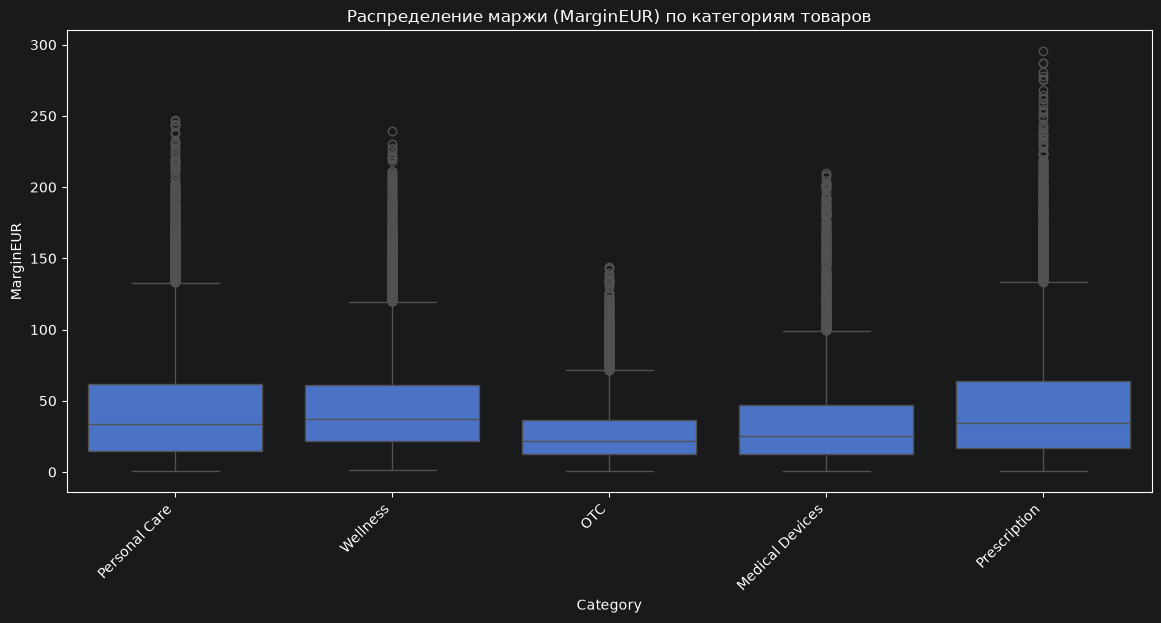

In [23]:
# Увеличим размер графика, чтобы категории не слипались
plt.figure(figsize=(14, 6))

# Строим boxplot: ось X - категории, ось Y - маржа (или выручка)
sns.boxplot(data=df_analysis, x='Category', y='MarginEUR')

# Поворачиваем подписи оси X, чтобы названия категорий читались
plt.xticks(rotation=45, ha='right')
plt.title('Распределение маржи (MarginEUR) по категориям товаров')

plt.show()

In [24]:
df_analysis.value_counts('PromoFlag')

PromoFlag
No     54708
Yes     7431
Name: count, dtype: int64

In [25]:
df_analysis.value_counts('Year')

Year
2025    31827
2024    30312
Name: count, dtype: int64

In [26]:
df_analysis.value_counts('MonthName')

MonthName
July         5441
December     5391
May          5352
October      5322
August       5271
January      5216
September    5202
June         5142
March        5120
November     5016
April        4920
February     4746
Name: count, dtype: int64

In [27]:
df_analysis.value_counts('Country')

Country
Germany        10628
France         10187
Italy           9872
Belgium         8280
Poland          6641
Netherlands     6138
Spain           5700
Austria         4693
Name: count, dtype: int64

In [28]:
df_analysis.value_counts('City')

City
Milan         3512
Hamburg       3066
Munich        3013
Lyon          2887
Utrecht       2772
Liège         2632
Naples        2598
Rotterdam     2417
Lille         2384
Frankfurt     2138
Venice        2108
Marseille     2040
Madrid        1973
Bordeaux      1950
Poznań        1824
Brussels      1669
Kraków        1583
Ghent         1500
Gdańsk        1493
Berlin        1477
Barcelona     1410
Bruges        1359
Vienna        1331
St. Pölten    1208
Bilbao        1195
Seville       1122
Antwerp       1120
Rome          1111
Katowice      1033
Salzburg       992
Cologne        934
Paris          926
Warsaw         708
Innsbruck      644
Amsterdam      634
Bologna        543
Graz           518
Arnhem         315
Name: count, dtype: int64

In [29]:
df_analysis.value_counts('PharmacyType')

PharmacyType
Urban       29552
Suburban    22403
Rural       10184
Name: count, dtype: int64

In [30]:
df_analysis.value_counts('Region')

Region
Lombardy                      3512
Hamburg                       3066
Bavaria                       3013
Auvergne-Rhône-Alpes          2887
Utrecht                       2772
Wallonia                      2632
Campania                      2598
South Holland                 2417
Hauts-de-France               2384
Hesse                         2138
Veneto                        2108
Provence-Alpes-Côte d'Azur    2040
Community of Madrid           1973
Nouvelle-Aquitaine            1950
Greater Poland                1824
Brussels-Capital              1669
Lesser Poland                 1583
East Flanders                 1500
Pomeranian                    1493
Berlin                        1477
Catalonia                     1410
West Flanders                 1359
Vienna                        1331
Lower Austria                 1208
Basque Country                1195
Andalusia                     1122
Flanders                      1120
Lazio                         1111
Silesian     

In [31]:
df_analysis.value_counts('StoreSizeBand')

StoreSizeBand
M    28181
L    19781
S    14177
Name: count, dtype: int64

In [32]:
df_analysis.value_counts('ProductName')

ProductName
PainLess Throat Lozenges 20 mg           722
ColdAway Paracetamol 200 mg              679
NutriCore Magnesium Max                  676
DigestEase Nasal Spray 200 mg            654
ZenHealth Probiotic Daily                641
                                        ... 
HairEssence Mouthwash Classic             34
DermaSoft Moisturizer Hydra               33
GlucoMeterX Pulse Oximeter Smart          31
HomeCheck Blood Pressure Monitor Home     22
HairEssence Hand Cream Repair             21
Name: count, Length: 203, dtype: int64

In [33]:
df_analysis.value_counts('Category')

Category
OTC                19412
Prescription       13120
Wellness           12483
Personal Care      11073
Medical Devices     6051
Name: count, dtype: int64

In [34]:
df_analysis.value_counts('IsGeneric')

IsGeneric
No     52302
Yes     9837
Name: count, dtype: int64

In [35]:
df_analysis.value_counts('PackSize')

PackSize
100 ml         7352
30 tablets     6334
500 g          3812
10 tablets     3166
50 g           3160
20 tablets     2972
250 g          2955
400 ml         2560
60 capsules    2449
200 ml         2430
1 pen          2304
90 tablets     2298
90 capsules    2195
60 tablets     2165
15 lozenges    2104
1 unit         2079
150 ml         1922
250 ml         1806
25 strips      1751
75 ml          1549
5 pens         1483
50 strips      1404
30 capsules    1072
10 strips       817
Name: count, dtype: int64

In [36]:
df_analysis.value_counts('IsDiscontinued')

IsDiscontinued
No     57094
Yes     5045
Name: count, dtype: int64

In [37]:
df_analysis.value_counts('LaunchDate')

LaunchDate
2018-06-07    702
2018-04-09    630
2022-02-17    623
2020-03-06    604
2024-07-31    544
             ... 
2016-09-24     38
2022-12-15     34
2020-02-12     33
2024-06-02     22
2016-02-24     21
Name: count, Length: 213, dtype: int64

In [38]:
df_analysis.value_counts('DiscontinuedDate')

DiscontinuedDate
2025-11-11    331
2025-11-09    306
2025-03-10    283
2025-09-10    278
2025-07-13    274
2025-10-02    253
2025-04-23    232
2025-07-07    212
2025-05-29    203
2025-06-05    199
2025-04-18    197
2025-06-09    182
2025-01-22    180
2025-07-02    174
2024-12-30    166
2025-04-08    163
2024-12-11    150
2024-10-14    147
2024-12-27    139
2024-12-09    134
2024-12-02    115
2024-08-30    103
2024-09-09    100
2024-08-01     84
2024-07-20     82
2024-09-04     68
2024-05-09     56
2024-05-23     55
2024-03-26     38
2024-05-05     34
2024-04-12     33
2024-04-20     31
2024-03-19     22
2024-03-12     21
Name: count, dtype: int64

# G. Correlation Analysis

<Axes: >

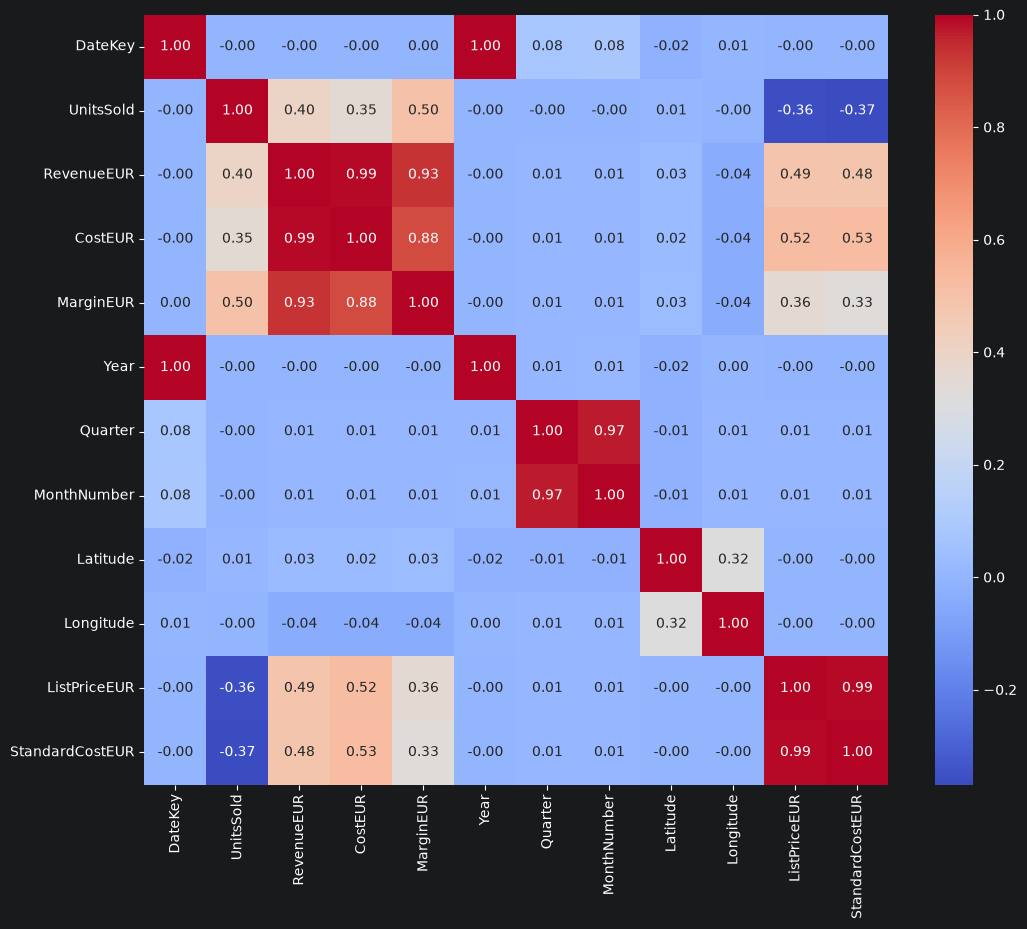

In [39]:
corr_matrix = df_analysis.corr(numeric_only=True)
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)


<Axes: >

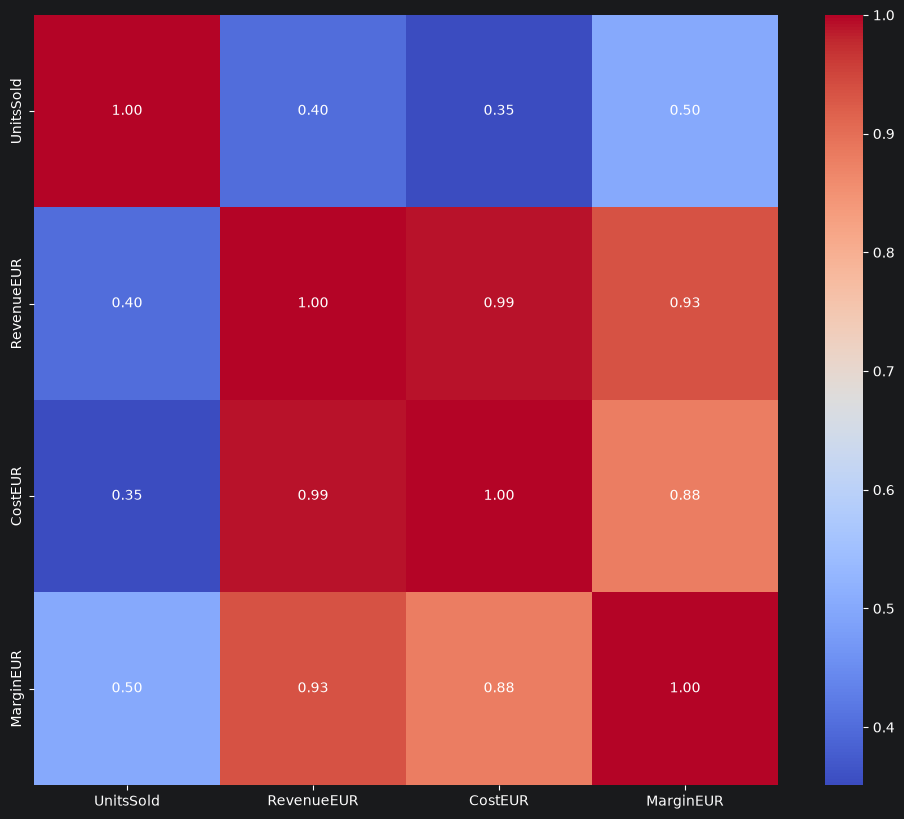

In [40]:
corr = df_analysis[
    [
        "UnitsSold",
        "RevenueEUR",
        "CostEUR",
        "MarginEUR"
    ]
].corr()
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

Correlation analysis revealed a very strong positive relationship between RevenueEUR and CostEUR (0.99), indicating that higher sales revenue is accompanied by higher costs. RevenueEUR also showed a strong positive correlation with MarginEUR (0.93). UnitsSold exhibited only moderate correlations with financial metrics (0.35–0.50), suggesting that the number of units sold alone does not fully explain revenue or profit because products differ in price and margin.

# Cleaning data

### Create a copy for data cleaning ###

In [41]:
df_analysis_for_clean: DataFrame = df_analysis.copy()

### No columns were removed because each feature may contribute to answering the business questions or creating meaningful visualizations. Geographic coordinates (Latitude and Longitude), for example, can be used for spatial analysis and mapping.

### transfer str type of data into data type

In [42]:
# DiscontinuedDate contains missing values because products that are not discontinued do not have a discontinued date. Therefore, these missing values are meaningful and should not be removed or filled.
df_analysis_for_clean['DiscontinuedDate'] = pd.to_datetime(df_analysis_for_clean['DiscontinuedDate'])
df_analysis_for_clean['DiscontinuedDate'].head(25)

0           NaT
1           NaT
2           NaT
3           NaT
4           NaT
5           NaT
6           NaT
7           NaT
8           NaT
9           NaT
10          NaT
11          NaT
12   2025-07-07
13          NaT
14          NaT
15          NaT
16          NaT
17   2025-11-11
18          NaT
19          NaT
20          NaT
21          NaT
22          NaT
23          NaT
24          NaT
Name: DiscontinuedDate, dtype: datetime64[us]

In [43]:
df_analysis_for_clean['LaunchDate'] = pd.to_datetime(df_analysis_for_clean['LaunchDate'])
df_analysis_for_clean['LaunchDate'].head()

0   2018-12-06
1   2021-05-21
2   2018-01-10
3   2017-05-26
4   2025-07-30
Name: LaunchDate, dtype: datetime64[us]

In [44]:
df_analysis_for_clean['OpenDate'] = pd.to_datetime(df_analysis_for_clean['OpenDate'])
df_analysis_for_clean['OpenDate'].head()

0   2011-12-21
1   2018-07-18
2   2017-07-25
3   2010-08-03
4   2011-01-16
Name: OpenDate, dtype: datetime64[us]

In [45]:
df_analysis_for_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 62139 entries, 0 to 62138
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   SalesID           62139 non-null  str           
 1   DateKey           62139 non-null  int64         
 2   PharmacyID        62139 non-null  str           
 3   ProductID         62139 non-null  str           
 4   UnitsSold         62139 non-null  int64         
 5   RevenueEUR        62139 non-null  float64       
 6   CostEUR           62139 non-null  float64       
 7   MarginEUR         62139 non-null  float64       
 8   PromoFlag         62139 non-null  str           
 9   Date              62139 non-null  datetime64[us]
 10  Year              62139 non-null  int64         
 11  Quarter           62139 non-null  int64         
 12  MonthNumber       62139 non-null  int64         
 13  MonthName         62139 non-null  str           
 14  YearMonth         62139 non-null 

In [46]:
df_analysis_for_clean.groupby(['Country', 'Category']).SalesID.count().reset_index()

,Country,Category,SalesID
0,Austria,Medical Devices,438
1,Austria,OTC,1506
2,Austria,Personal Care,811
3,Austria,Prescription,977
4,Austria,Wellness,961
5,Belgium,Medical Devices,807
6,Belgium,OTC,2599
7,Belgium,Personal Care,1566
8,Belgium,Prescription,1703
9,Belgium,Wellness,1605


In [47]:
df_analysis_for_clean.groupby(['City', 'Category']).SalesID.count().reset_index(name='Sales_Count')

,City,Category,Sales_Count
0,Amsterdam,Medical Devices,70
1,Amsterdam,OTC,192
2,Amsterdam,Personal Care,119
3,Amsterdam,Prescription,122
4,Amsterdam,Wellness,131
...,...,...,...
185,Warsaw,Medical Devices,64
186,Warsaw,OTC,193
187,Warsaw,Personal Care,138
188,Warsaw,Prescription,157


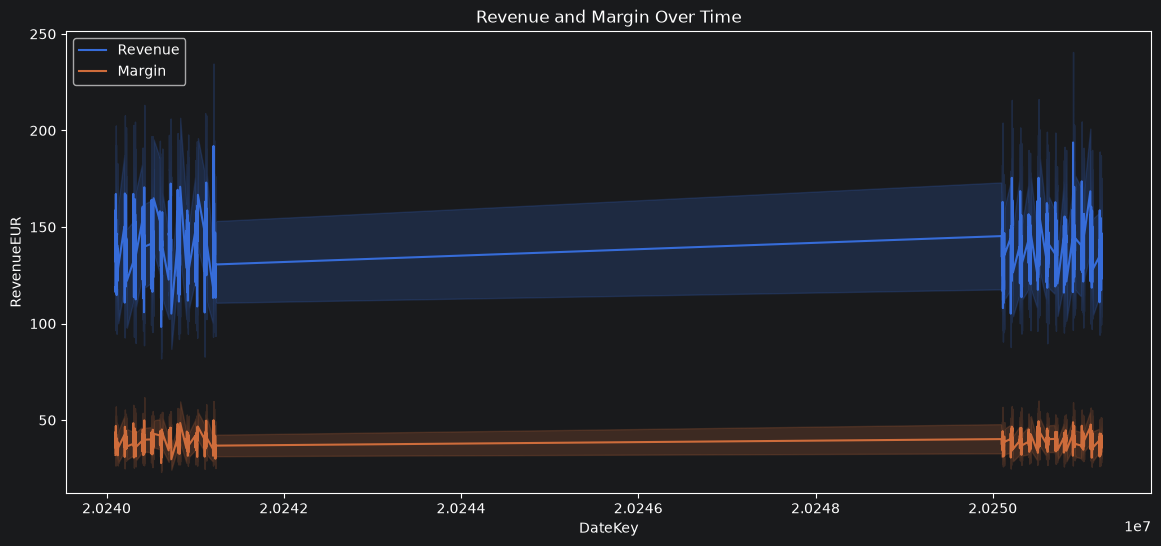

In [56]:
# Постройте линейные диаграммы для анализа изменений по времени
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_analysis_for_clean, x='DateKey', y='RevenueEUR', label='Revenue')
sns.lineplot(data=df_analysis_for_clean, x='DateKey', y='MarginEUR', label='Margin')
plt.title('Revenue and Margin Over Time')
plt.legend()
plt.show()

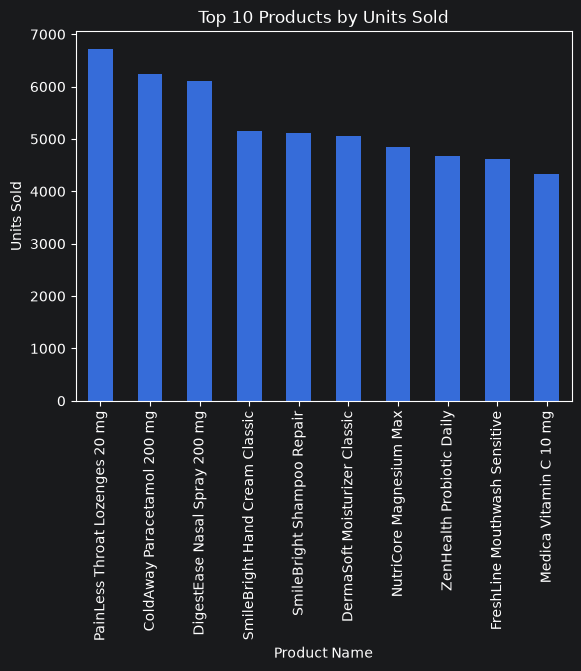

In [55]:
# Постройте график для анализа продаж по продуктам
df_analysis_for_clean.groupby('ProductName')['UnitsSold'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Products by Units Sold')
plt.xlabel('Product Name')
plt.ylabel('Units Sold')
plt.show()

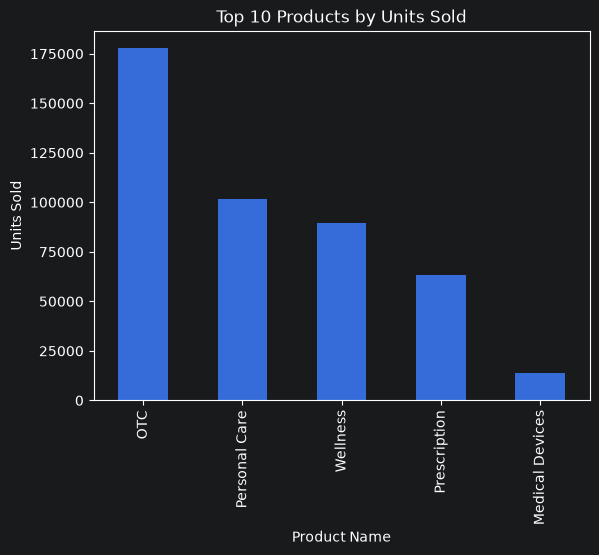

In [57]:
df_analysis_for_clean.groupby('Category')['UnitsSold'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Products by Units Sold')
plt.xlabel('Product Name')
plt.ylabel('Units Sold')
plt.show()